# Core Deep Learning Architectures for Time Series

**Docker image**: `ml4t-gpu`

Four neural networks read the same input - the last sixty daily returns of one
exchange-traded fund - and each predicts that fund's return on the next day. They
differ only in how they consume the window. A fully connected network flattens it
into one long vector. A one-dimensional convolution slides a small filter along it.
An LSTM and a GRU walk it one day at a time, carrying a running summary forward.
That last habit is what this notebook measures: walking a window step by step costs
compute that grows with the window, and whether it buys any accuracy is the question
the rest of the chapter works on.

**Learning objectives**:
- Build a fully connected network, a one-dimensional convolution, an LSTM and a GRU
  in PyTorch over one shared input, so that architecture is the only thing that
  differs between them.
- Read a training-loss curve against the error the same network makes on days it was
  not trained on, so a falling training curve is not mistaken for a better forecast.
- Time one training step for each network in milliseconds, and put that cost beside
  the error each one reaches.
- Watch that cost change as the input window is lengthened, and see why a network
  that walks the window scales differently from one that reads it all at once.

**Book Reference**: Chapter 13, Section 13.1 (Recurrent networks and their limits).
See Hochreiter and Schmidhuber (1997) for the original LSTM formulation.

**Prerequisites**: ETF price data (via the `load_etfs()` canonical loader).

In [1]:
"""Core Deep Learning Architectures - compare MLP, CNN, LSTM, and GRU for return prediction."""

import os

# Set before the first CUDA/cuBLAS call so deterministic GEMM kernels are available
# (see the Reproducibility note below); harmless on CPU.
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import time
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from ml4t.diagnostic.metrics import cross_sectional_ic_series

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, show_with_alt

In [2]:
SEED = 42
LOOKBACK = 60
HORIZON = 1
HIDDEN_SIZE = 64
EPOCHS = 50
BATCH_SIZE = 32
SYMBOLS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "USO"]
START_DATE = "2015-01-01"
LOOKBACKS = [30, 60, 120, 240]
VALIDATION_START = 0.65
TEST_START = 0.80

## Getting the same numbers twice

Fixing a seed is not enough to make GPU training repeat exactly. A seed fixes the
random choices - which weights the network starts from, which order the windows are
shuffled into - but a GPU adds a batch of floating-point numbers by splitting the sum
across thousands of cores and combining the pieces, and the order in which those
pieces arrive can differ between two runs of the same code. Floating-point addition
is not associative, so a different order gives a very slightly different sum, and
fifty epochs of very slightly different sums end in a visibly different model.

`torch.use_deterministic_algorithms(True)` tells PyTorch to refuse any operation
without a fixed-order implementation and to use the fixed-order variant everywhere
one exists. `CUBLAS_WORKSPACE_CONFIG`, set at the top of the notebook before the
first CUDA call, is what makes those variants available for the matrix
multiplications. `seed_all` re-asserts both and re-seeds, and it is called
immediately before each network is built so that all four start from the same
stream, whatever ran before them.

What this buys is repetition on one machine with one build of PyTorch. A different
GPU will give slightly different numbers, and timings are not covered at all - those
depend on what else the machine is doing.

In [3]:
def seed_all(seed: int = SEED) -> None:
    """Seed Python/NumPy/Torch and re-assert fixed-order execution."""
    set_global_seeds(seed)
    torch.use_deterministic_algorithms(True, warn_only=False)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

seed_all(SEED)

Using device: cuda


## The data

The inputs are daily closing prices for eight exchange-traded funds, each of which
tracks a broad basket rather than a single company. They are chosen to span very
different sources of risk - US large caps, US small caps, developed and emerging
markets outside the US, long-dated Treasuries, gold and crude oil - so that a result
reported below is not a property of one market. A price is converted to a daily
**return**, the fractional change from the previous close, because returns are
roughly comparable in size across funds trading at very different price levels, and
a network trained on raw prices would mostly learn each fund's price level.

The eight are held fixed for the whole period. All eight already existed and traded
throughout, so no fund enters or leaves the sample and nothing here depends on
knowing which funds survived.

In [5]:
EXPOSURE = {
    "SPY": "US large-cap equity",
    "QQQ": "US large-cap growth equity",
    "IWM": "US small-cap equity",
    "EFA": "Developed non-US equity",
    "EEM": "Emerging-market equity",
    "TLT": "Long-dated US Treasuries",
    "GLD": "Gold",
    "USO": "Crude oil",
}

In [6]:
etf_df = load_etfs()

start_dt = datetime.fromisoformat(START_DATE)

close_wide = (
    etf_df.filter(pl.col("symbol").is_in(SYMBOLS) & (pl.col("timestamp") >= start_dt))
    .pivot(on="symbol", values="close", index="timestamp")
    .drop_nulls()
    .sort("timestamp")
)

feature_cols = [c for c in close_wide.columns if c != "timestamp"]
returns = close_wide.with_columns(
    [pl.col(c).pct_change().alias(c) for c in feature_cols]
).drop_nulls()

### What the eight funds look like

A row per fund: what it is exposed to, and the annualised standard deviation of its
daily returns over the sample - daily standard deviation scaled by $\sqrt{252}$,
the number of trading days in a year. The spread across that column is the point.
Crude oil moves several times as much per day as long-dated Treasuries, and the
same network, trained the same way, sees both. The date range and the number of
trading days are shared: the wide-format table above keeps only dates on which all
eight funds traded, so every fund contributes the same days.

In [7]:
profile = pl.DataFrame(
    {
        "Symbol": SYMBOLS,
        "Exposure": [EXPOSURE[s] for s in SYMBOLS],
        "Annualised volatility (%)": [
            round(float(returns[s].std()) * np.sqrt(252) * 100, 1) for s in SYMBOLS
        ],
    }
)
print(
    f"{returns.height} trading days shared by all {len(SYMBOLS)} funds, "
    f"{returns['timestamp'][0]} to {returns['timestamp'][-1]}"
)
profile

2765 trading days shared by all 8 funds, 2015-01-05 to 2025-12-31


Symbol,Exposure,Annualised volatility (%)
str,str,f64
"""SPY""","""US large-cap equity""",17.8
"""QQQ""","""US large-cap growth equity""",22.0
"""IWM""","""US small-cap equity""",22.5
"""EFA""","""Developed non-US equity""",17.2
"""EEM""","""Emerging-market equity""",20.4
"""TLT""","""Long-dated US Treasuries""",15.0
"""GLD""","""Gold""",14.7
"""USO""","""Crude oil""",38.8


## Turning the return series into training examples

One training example is a **window**: the previous `LOOKBACK` daily returns of one
fund, paired with that fund's return `HORIZON` days later. Sliding the window
forward one day at a time turns each fund's return series into thousands of
overlapping examples, and stacking all eight funds gives one pooled set. Pooling is
deliberate - a single network is fitted to all eight rather than one network per
fund, so the comparison below is not decided by whichever fund happened to be easy.

The target is the next day's return. Next-day returns are close to unpredictable,
and that is the point: an objective with almost no signal keeps the notebook's
attention on what the architectures cost rather than on which one wins.

### Sliding one window along one fund

`create_sequences` takes one fund's return series and returns the stack of windows
and the matching targets. Window `i` covers positions `i` through `i + lookback - 1`
and its target sits at `i + lookback + horizon - 1`, so no window ever contains its
own target.

In [8]:
def create_sequences(data: np.ndarray, lookback: int, horizon: int):
    """Create univariate input sequences with next-horizon return targets."""
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback + horizon - 1])
    return np.array(X), np.array(y)

### Splitting on dates, not on window counts

The three stretches are defined by **calendar position**, at the fractions
`VALIDATION_START` and `TEST_START` of the trading days in the sample. Each example
is placed by the day its target falls on: targets before the first boundary train
the networks, targets between the boundaries are scored after every epoch but never
trained on, and targets after the second boundary are scored once, at the end.
Nothing in the notebook - not a weight, not a stopping point, not a choice of
architecture - is decided using the third stretch.

Anchoring on the target's date rather than on a fraction of the window count is what
makes the window-length sweep later in the notebook mean anything. A window of
`lookback` days cannot start until `lookback` days of history exist, so a longer
window yields fewer examples; cutting a fixed fraction of *those* would put the
validation stretch on different dates for every window length, and the sweep would
be comparing market periods rather than architectures. Placing every example by its
target date fixes the validation and test dates once, for all lengths.

One gap is still needed. An example's target is a single day's return `HORIZON` days
after its window ends, so training stops `HORIZON` days short of the first
validation target: no day the network was fitted on lies within a forecast horizon
of the first day it is scored on. `first_target_pos` lets a caller start every
example set at the same date as well, which the sweep uses so that changing the
window length changes how much history each example sees and nothing else.

In [9]:
def create_panel_sequences(
    returns_df: pl.DataFrame,
    symbols: list[str],
    lookback: int,
    horizon: int,
    val_start_fraction: float = VALIDATION_START,
    test_start_fraction: float = TEST_START,
    first_target_pos: int | None = None,
) -> dict[str, np.ndarray]:
    """Pool per-symbol windows into train / validation / test stretches fixed by date."""
    timestamps = returns_df["timestamp"].to_numpy()
    n_days = len(timestamps)
    val_start = int(n_days * val_start_fraction)
    test_start = int(n_days * test_start_fraction)
    earliest = lookback + horizon - 1
    target_pos = np.arange(earliest, n_days)  # aligns element-wise with create_sequences
    selectors = {
        "train": (target_pos >= max(earliest, first_target_pos or earliest))
        & (target_pos < val_start - horizon),
        "val": (target_pos >= val_start) & (target_pos < test_start - horizon),
        "test": target_pos >= test_start,
    }
    if any(sel.sum() == 0 for sel in selectors.values()):
        raise ValueError(f"lookback {lookback}: a stretch came out empty")

    parts: dict[str, list[np.ndarray]] = {
        f"{axis}_{split}": [] for split in selectors for axis in ("X", "y")
    }
    parts |= {"test_dates": [], "test_symbols": []}
    for symbol in symbols:
        X_symbol, y_symbol = create_sequences(returns_df[symbol].to_numpy(), lookback, horizon)
        for split, sel in selectors.items():
            parts[f"X_{split}"].append(X_symbol[sel])
            parts[f"y_{split}"].append(y_symbol[sel])
        parts["test_dates"].append(timestamps[target_pos[selectors["test"]]])
        parts["test_symbols"].append(np.full(int(selectors["test"].sum()), symbol))
    return {name: np.concatenate(chunks) for name, chunks in parts.items()}

### Scoring a forecast: the information coefficient

Squared error says how far a prediction is from the realised return. It does not say
whether the prediction was useful, because a trader acts on the ordering: buy the
funds predicted to do best, avoid the ones predicted to do worst. The
**information coefficient**, or IC, measures that ordering directly. On each date,
rank the eight funds by prediction, rank them again by what they actually returned,
and take the correlation between the two sets of ranks - the Spearman rank
correlation. It is `+1` when the predicted order is exactly right, `-1` when it is
exactly reversed, and `0` when the prediction carries no ordering information. The
notebook then averages that daily figure over the test dates.

Two settings matter. `min_obs=5` scores a date on which at least five of the eight
funds are present; the library's default of ten would discard every date in an
eight-fund panel. And on a date where a network predicts the *same* number for all
eight, the predicted ranks are all tied, the correlation has nothing to correlate,
and the library returns `NaN`. Those dates are dropped from the average and counted
separately as **coverage**, so a network that ties often is visible rather than
hidden behind an average taken over whichever dates happened to survive. The drop
has to test for `NaN` explicitly: polars treats `NaN` and null as different values,
and `drop_nulls` leaves `NaN` in place, where a single one would make the mean
`NaN` as well.

In [10]:
def cross_sectional_ic(y_true, y_pred, dates, symbols):
    """Mean cross-sectional Spearman IC over defined dates, plus date coverage.

    Returns a dict with the mean IC (over dates where it is defined), and the
    counts of defined vs total dates. A date's IC is `NaN` when the model's
    predictions are tied across all symbols (zero rank variance); those dates are
    excluded from the mean (filtering both null and NaN, since polars `drop_nulls`
    leaves NaN in place).
    """
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
        min_obs=5,
    )
    defined = ic_per_date.filter(pl.col("ic").is_not_null() & pl.col("ic").is_not_nan())
    n_total = ic_per_date.height
    n_defined = defined.height
    mean_ic = float(defined["ic"].mean()) if n_defined else float("nan")
    return {"ic": mean_ic, "n_defined": n_defined, "n_total": n_total}

### Building the three stretches

PyTorch wants a tensor shaped `(examples, time steps, features)`; there is one
feature here, the return, so the window gains a trailing axis of length one.

In [11]:
def to_tensor(array: np.ndarray) -> torch.Tensor:
    """Move one array of windows or targets onto the compute device."""
    return torch.FloatTensor(array).unsqueeze(-1).to(DEVICE)

In [12]:
splits = create_panel_sequences(returns, SYMBOLS, LOOKBACK, HORIZON)
test_dates, test_symbols = splits["test_dates"], splits["test_symbols"]

X_train_t, y_train_t = to_tensor(splits["X_train"]), to_tensor(splits["y_train"])
X_val_t, y_val_t = to_tensor(splits["X_val"]), to_tensor(splits["y_val"])
X_test_t, y_test_t = to_tensor(splits["X_test"]), to_tensor(splits["y_test"])

print(
    f"Windows of {LOOKBACK} days pooled over {len(SYMBOLS)} funds: "
    f"{len(splits['X_train']):,} for training, {len(splits['X_val']):,} for watching, "
    f"{len(splits['X_test']):,} held to the end"
)
print(
    f"Held-back targets run {splits['test_dates'].min()} to {splits['test_dates'].max()}; "
    f"training stops {HORIZON} trading day(s) short of each boundary"
)

Windows of 60 days pooled over 8 funds: 13,888 for training, 3,312 for watching, 4,424 held to the end
Held-back targets run 2023-10-18 to 2025-12-31; training stops 1 trading day(s) short of each boundary


## The four networks

All four take the same window and return one number. What differs is how the window
is consumed, and each choice carries a different assumption about where the useful
structure in a return series is.

They are **not** matched on size. Each is written the way its architecture is
normally written at `HIDDEN_SIZE` units, and the parameter counts that fall out of
that differ several-fold; the counts are printed with the results so the cost figures
can be read against them. Equalising the counts would mean shrinking the recurrent
networks to sizes nobody uses, which would answer a question the chapter is not
asking.

### The fully connected network

The window is flattened into a single vector of `lookback` numbers and passed
through three fully connected layers. Flattening throws away the fact that the
numbers are ordered in time: position 3 and position 47 are just two input slots,
and the network has to learn any relation between them from data. In exchange, every
input is available at once, so the whole forward pass is a handful of matrix
multiplications and nothing waits for anything else.

In [13]:
class MLPForecaster(nn.Module):
    def __init__(self, lookback: int, hidden_size: int):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(lookback, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

### The one-dimensional convolution

A **convolution** slides a short filter - here three days wide - along the window and
records what it finds at each position. The same filter is reused everywhere, so a
pattern the network learns to recognise on day 5 is recognised on day 50 without
being learned again, which is what makes a convolution far smaller than a fully
connected layer over the same input. Every position is filtered independently, so
the whole slide happens at once.

`padding=1` keeps the output the same length as the input by adding a zero at each
end. That means the filter centred on the last day reads a padded slot to its right
rather than a future return - no future information enters - but a filter centred
earlier does see days after its centre. That is harmless here, because the whole
window already lies in the past of the target. `05_tcn` builds the strictly causal
version, where each position sees only what precedes it.

In [14]:
class CNNForecaster(nn.Module):
    def __init__(self, lookback: int, hidden_size: int):
        super().__init__()
        self.conv1 = nn.Conv1d(1, hidden_size // 2, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden_size // 2, hidden_size, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_size, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

### The LSTM

A **recurrent** network walks the window one day at a time, carrying a vector called
the hidden state from step to step. At day $t$ it combines the day's return with the
hidden state produced at day $t-1$, and writes a new hidden state; the prediction is
read off the state after the last day. The **long short-term memory** network, or
LSTM, is the standard version of this idea: alongside the hidden state it keeps a
second vector, the cell state, and learns three small gates that decide what to add
to it, what to erase from it, and how much of it to expose. The gates are what let it
hold information across dozens of steps, where a plain recurrent network loses it.

The design has one consequence this notebook measures. Step $t$ cannot start until
step $t-1$ has finished, so a window of $T$ days takes $T$ dependent operations no
matter how much hardware is available. A GPU is fast because it runs thousands of
arithmetic operations simultaneously, and a chain of dependent steps is exactly the
shape it cannot accelerate. Section 13.1 is where the chapter argues this from the
architecture; the timing below is where the notebook measures it.

In [15]:
class LSTMForecaster(nn.Module):
    def __init__(self, hidden_size: int, num_layers: int = 2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

### The GRU

The **gated recurrent unit**, or GRU, is a lighter recurrent design. It drops the
separate cell state and merges the LSTM's forget and input gates into one update
gate, which leaves it with fewer weights to learn per step. Fewer weights often
means it fits a small dataset with less trouble than an LSTM. What it does not
change is the walk: it still processes the window one day at a time, so it carries
the same dependency between steps.

In [16]:
class GRUForecaster(nn.Module):
    def __init__(self, hidden_size: int, num_layers: int = 2):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        return self.fc(gru_out[:, -1, :])

## Training, and watching two losses at once

One pass over the training windows is an **epoch**; the loop below runs `EPOCHS` of
them, shuffling the windows each time and updating the weights on batches of
`BATCH_SIZE`. The quantity being minimised is the mean squared error between
prediction and realised return.

At the end of every epoch the same error is also computed on the validation
stretch, which no weight update has seen. Recording both is what makes the loss
curve readable. Training error falls whenever the network finds structure in the
training windows, and a return series offers plenty of structure that is specific to
the days it happened on - a network with enough capacity will fit it, and doing so
improves nothing about a later day. Validation error is what says whether a fall in
training error meant anything. Nothing is selected on the validation figure here:
every network trains for the full `EPOCHS` and the curve is read, not acted on.

In [17]:
def evaluate_mse(model, X, y) -> float:
    """Mean squared error of the model on one stretch, with no weight update."""
    model.eval()
    with torch.no_grad():
        return float(nn.functional.mse_loss(model(X), y).item())

In [18]:
def train_model(model, X_train, y_train, epochs, batch_size, model_name, X_val=None, y_val=None):
    """Train a model in place; return its per-epoch training and validation losses."""
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    n_samples = len(X_train)
    history: dict[str, list[float]] = {"train": [], "val": []}
    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        indices = torch.randperm(n_samples, device=DEVICE)
        for i in range(0, n_samples, batch_size):
            batch_idx = indices[i : i + batch_size]
            optimizer.zero_grad()
            loss = criterion(model(X_train[batch_idx]), y_train[batch_idx])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        train_loss = epoch_loss / n_batches
        history["train"].append(train_loss)
        if X_val is not None:
            history["val"].append(evaluate_mse(model, X_val, y_val))
        if (epoch + 1) % 10 == 0 or epoch == 0:
            tail = f", validation {history['val'][-1]:.6f}" if history["val"] else ""
            print(f"{model_name} epoch {epoch + 1}/{epochs}: training {train_loss:.6f}{tail}")
    return history

### Timing one training step

Total training time is a poor measure of what an architecture costs. Anything else
running on the same GPU inflates it, and at `BATCH_SIZE` of 32 much of each epoch is
spent in Python launching work rather than doing it, which flatters and penalises
architectures unequally.

What is timed instead is a single training step - one forward pass, one backward
pass, one weight update - on a fixed batch of `BENCH_BATCH` windows. The first
`warmup` steps are discarded, because the first call into a GPU kernel pays for
memory allocation and kernel compilation that no later call repeats. The step is
then run `repeats` times and the **fastest** of those is reported. Taking the
minimum rather than the mean is deliberate: the true cost of the step is a floor,
and everything that moves a measurement above it - a scheduler preemption, another
process - only adds. On a GPU the timing uses CUDA events rather than the wall
clock, because a GPU call returns to Python before the work finishes and a wall
clock would time the queueing, not the arithmetic.

The result still depends on the machine. Read the ordering between architectures and
how it changes with window length; do not read the milliseconds as a property of the
architecture.

In [19]:
BENCH_BATCH = 256

In [20]:
def benchmark_step(model, x, y, repeats: int = 100, warmup: int = 20) -> float:
    """Return the fastest observed step time; the result remains load-sensitive."""
    model.to(DEVICE)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    def _one_step() -> None:
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    for _ in range(warmup):
        _one_step()

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
        times = []
        for _ in range(repeats):
            start = torch.cuda.Event(enable_timing=True)
            end = torch.cuda.Event(enable_timing=True)
            start.record()
            _one_step()
            end.record()
            torch.cuda.synchronize()
            times.append(start.elapsed_time(end))
        return min(times)

    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        _one_step()
        times.append((time.perf_counter() - t0) * 1000.0)
    return min(times)

## Running the comparison

The dictionary below holds constructors rather than built models. Each is called
inside the loop, immediately after re-seeding, so all four start from weights drawn
from the same seeded stream and none of them inherits a state left behind by
whichever architecture was trained before it.

In [21]:
model_builders = {
    "MLP": lambda: MLPForecaster(LOOKBACK, HIDDEN_SIZE),
    "CNN": lambda: CNNForecaster(LOOKBACK, HIDDEN_SIZE),
    "LSTM": lambda: LSTMForecaster(HIDDEN_SIZE),
    "GRU": lambda: GRUForecaster(HIDDEN_SIZE),
}

results = {}

### Fit each architecture, then score it on the held-back stretch

In [22]:
for name, build in model_builders.items():
    seed_all(SEED)
    model = build()
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nTraining {name} ({n_params:,} parameters)...")

    history = train_model(model, X_train_t, y_train_t, EPOCHS, BATCH_SIZE, name, X_val_t, y_val_t)

    model.eval()
    with torch.no_grad():
        predictions = model(X_test_t).cpu().numpy().flatten()
        actuals = y_test_t.cpu().numpy().flatten()

    mse = float(np.mean((predictions - actuals) ** 2))
    ic_info = cross_sectional_ic(actuals, predictions, test_dates, test_symbols)

    results[name] = {
        "mse": mse,
        "ic": ic_info["ic"],
        "ic_coverage": (ic_info["n_defined"], ic_info["n_total"]),
        "n_params": n_params,
        "history": history,
    }


Training MLP (8,129 parameters)...


MLP epoch 1/50: training 0.000211, validation 0.000232


MLP epoch 10/50: training 0.000147, validation 0.000255


MLP epoch 20/50: training 0.000118, validation 0.000287


MLP epoch 30/50: training 0.000102, validation 0.000328


...

GRU epoch 10/50: training 0.000207, validation 0.000230


GRU epoch 20/50: training 0.000205, validation 0.000230


GRU epoch 30/50: training 0.000205, validation 0.000234


GRU epoch 40/50: training 0.000204, validation 0.000234


GRU epoch 50/50: training 0.000204, validation 0.000230


### Time a step for each architecture

Timing runs only after every network has been fitted, so a benchmark cannot change
the GPU state a later fit runs in. Each timing uses a freshly seeded network of the
same architecture rather than the trained one, because a trained network and an
untrained one do the same arithmetic per step.

In [23]:
for name, build in model_builders.items():
    seed_all(SEED)
    bench_model = build()
    n_bench = min(BENCH_BATCH, len(X_train_t))
    results[name]["step_ms"] = benchmark_step(bench_model, X_train_t[:n_bench], y_train_t[:n_bench])

## What each architecture cost and what it produced

One row per architecture. **Parameters** is how many weights it has to learn.
**Step time** is the timed training step from above. **Test MSE** is the squared
error on the final stretch, which is also the quantity that was minimised.
**IC** is the average daily ranking correlation defined earlier, and
**IC coverage** counts the test dates on which it was defined at all - a network
that predicts one number for all eight funds has no ordering to score that day, and
a coverage figure well below the total says the average beside it was taken over a
subset chosen by the network's own behaviour.

The two error columns answer different questions and can disagree. A network can
have the lower squared error because it predicts closer to zero every day, while
ranking the funds no better than chance; another can rank slightly better while
sitting further from the realised values. Read them together.

In [24]:
comparison_df = pl.DataFrame(
    [
        {
            "Model": name,
            "Parameters": r["n_params"],
            "Step time (ms)": round(r["step_ms"], 3),
            "Test MSE": round(r["mse"], 6),
            "IC": "undefined" if np.isnan(r["ic"]) else f"{r['ic']:.4f}",
            "IC coverage": f"{r['ic_coverage'][0]}/{r['ic_coverage'][1]}",
        }
        for name, r in results.items()
    ]
)
comparison_df

Model,Parameters,Step time (ms),Test MSE,IC,IC coverage
str,i64,f64,f64,str,str
"""MLP""",8129,0.113,0.000215,"""0.0030""","""553/553"""
"""CNN""",6401,0.314,0.000148,"""0.0345""","""553/553"""
"""LSTM""",50497,1.356,0.000149,"""0.0012""","""553/553"""
"""GRU""",37889,1.361,0.000148,"""0.0105""","""553/553"""


Whatever the ordering in the two error columns turns out to be, it is one split of
one eight-fund panel on a target with almost no signal, and it is not a reason to
prefer one of these architectures over another. Next-day returns are close to
unpredictable, so squared error is minimised largely by predicting near the average,
and the ranking correlations are small. Whether any gap between them is real is a
question this notebook gives no way to answer: there is one split, one seed, and no
interval around any of these averages. Establishing that a difference in ranking
correlation is more than sampling noise takes repeated splits and a standard error on
each average, which is what Chapter 6's walk-forward procedure and the case-study
notebooks are for.

The cost column is the one that carries information, because it measures a property
of the architecture rather than an accident of this sample: a network that walks the
window one day at a time has to do work that a network reading it all at once does
not. The rest of the notebook pursues that column.

### Reading the two loss curves

One panel per architecture, all four on the same axes limits so the heights are
comparable, each showing per-epoch mean squared error on the pooled eight-fund
next-day return target. The solid line is the training error the network is
minimising; the dashed line is the same error on the validation windows, which no
weight update touched.

Three readings are possible and all three appear below. Both lines falling together
means the network found structure that holds on days it has not seen. Both lines
flat means it found nothing and settled for predicting near the average - on a
next-day return target that is the honest outcome, not a failure. The solid line
falling while the dashed line **rises** means the network is fitting the training
days themselves, and every epoch after the dashed line turns is making the forecast
worse while the number being minimised keeps improving. That last shape is why the
second curve is worth its one forward pass per epoch: nothing in the training loss
distinguishes it from the first.

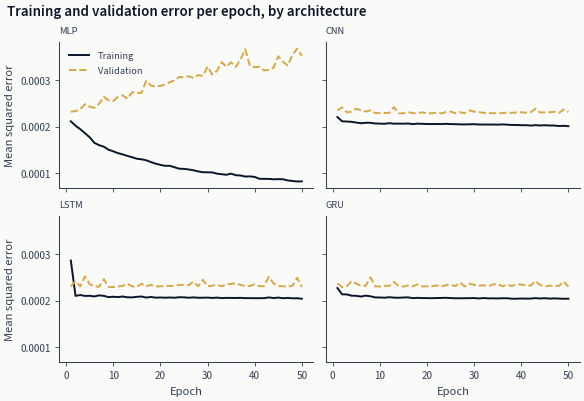

In [25]:
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE["grid_2x2"], sharex=True, sharey=True)

for ax, (name, r) in zip(axes.flat, results.items(), strict=True):
    epochs_axis = range(1, len(r["history"]["train"]) + 1)
    ax.plot(epochs_axis, r["history"]["train"], color=COLORS["blue"], label="Training")
    ax.plot(
        epochs_axis,
        r["history"]["val"],
        color=COLORS["amber"],
        linestyle="--",
        label="Validation",
    )
    ax.set_title(name, loc="left", fontsize="small")

for ax in axes[-1]:
    ax.set_xlabel("Epoch")
for ax in axes[:, 0]:
    ax.set_ylabel("Mean squared error")
axes.flat[0].legend(frameon=False, fontsize="small")

# A figure-level title, because each axes' left title already carries its architecture.
fig.suptitle(
    "Training and validation error per epoch, by architecture",
    x=0.01,
    ha="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
show_with_alt(
    fig,
    "Four panels, one per architecture, each plotting mean squared error against "
    "training epoch. Every panel carries a solid training curve and a dashed "
    "validation curve on shared axes, so the epoch at which the two separate is "
    "visible for each architecture.",
)

### Cost against error

The scatter puts the timed step on the horizontal axis and the error on the final
stretch on the vertical one, so an architecture sitting far to the right has to
justify itself by sitting low. Squared error is used rather than the ranking
correlation because it is defined on every date, whereas the correlation is not.

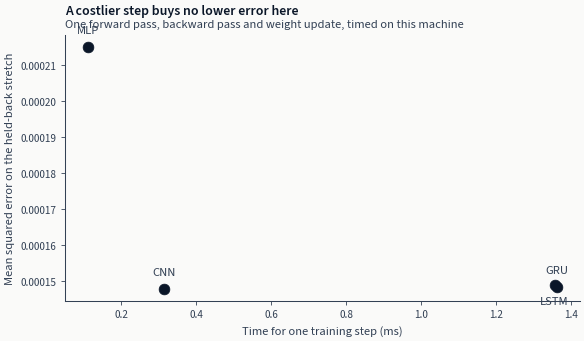

In [26]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])

for name, r in results.items():
    ax.scatter(r["step_ms"], r["mse"], s=60, color=COLORS["blue"], zorder=5)
    ax.annotate(
        name,
        (r["step_ms"], r["mse"]),
        textcoords="offset points",
        xytext=(0, -14 if name == "LSTM" else 10),
        ha="center",
    )
ax.set_xlabel("Time for one training step (ms)")
ax.set_ylabel("Mean squared error on the held-back stretch")
add_message_title(
    ax,
    "A costlier step buys no lower error here",
    subtitle="One forward pass, backward pass and weight update, timed on this machine",
)
show_with_alt(
    fig,
    "A scatter of four labelled points, one per architecture, with the time for a "
    "single training step in milliseconds across the horizontal axis and mean "
    "squared error on the held-back stretch up the vertical axis.",
)

The horizontal spread is large and the vertical spread is small: the architectures
separate on what a step costs far more clearly than on what it achieves. On a target
this close to unpredictable that is the expected outcome, and it is the useful one -
a step that costs several times as much has to be earning something, and here there
is nothing on the vertical axis for it to earn. The rest of Chapter 13 is largely a
search for architectures that keep the accuracy while dropping the walk.

## Lengthening the window

The step timings above were all taken at one window length. The claim they are meant
to support is about how that cost behaves as the window grows, and one length cannot
show it. So the fully connected network and the LSTM are rebuilt at each length in
`LOOKBACKS` and timed again.

The two should grow differently, for reasons visible in the code rather than in the
measurement. The LSTM's weights do not depend on the window at all - it applies the
same step to each day - so a longer window buys it no parameters and costs it
proportionally more dependent steps. The fully connected network has the opposite
shape: its first layer has one weight per input day, so a longer window makes that
one matrix multiplication bigger, and a bigger matrix multiplication is work a GPU
spreads across its cores. What the panel below measures is whether the two costs
behave as those two shapes predict.

Each length also gets a fitted pair scored on the validation stretch, so the second
question - whether the extra history is worth anything - is answered on the same
axis as the cost. Nothing selects a window length from either panel.

Two things are held fixed so the sweep varies one thing. The validation dates are
already fixed by the date-anchored split. `SWEEP_FIRST_TARGET` fixes the other end:
every length starts its examples on the date the longest window can first reach, so
all four are fitted on the same days and the same number of examples. Without it the
shorter windows would train on several hundred extra examples each, and a difference
in error could be read as a difference in sample size.

In [27]:
scaling_architectures = [
    ("MLP", MLPForecaster, lambda lb: {"lookback": lb, "hidden_size": HIDDEN_SIZE}),
    ("LSTM", LSTMForecaster, lambda _lb: {"hidden_size": HIDDEN_SIZE}),
]

scaling_results: dict[tuple[str, int], dict[str, float]] = {}
scaling_batches: dict[int, tuple[torch.Tensor, torch.Tensor]] = {}

In [28]:
SWEEP_FIRST_TARGET = max(LOOKBACKS) + HORIZON - 1

for lb in LOOKBACKS:
    lb_splits = create_panel_sequences(
        returns, SYMBOLS, lb, HORIZON, first_target_pos=SWEEP_FIRST_TARGET
    )
    X_tr, y_tr = to_tensor(lb_splits["X_train"]), to_tensor(lb_splits["y_train"])
    X_va, y_va = to_tensor(lb_splits["X_val"]), to_tensor(lb_splits["y_val"])
    scaling_batches[lb] = (X_tr, y_tr)

    for arch_name, ModelCls, kwargs_for in scaling_architectures:
        seed_all(SEED)
        model = ModelCls(**kwargs_for(lb))
        history = train_model(
            model, X_tr, y_tr, EPOCHS, BATCH_SIZE, f"{arch_name}-{lb}", X_va, y_va
        )
        scaling_results[(arch_name, lb)] = {
            "train_mse": history["train"][-1],
            "val_mse": history["val"][-1],
        }

MLP-30 epoch 1/50: training 0.000268, validation 0.000237


MLP-30 epoch 10/50: training 0.000168, validation 0.000239


MLP-30 epoch 20/50: training 0.000148, validation 0.000275


MLP-30 epoch 30/50: training 0.000135, validation 0.000262


MLP-30 epoch 40/50: training 0.000125, validation 0.000287


...

LSTM-240 epoch 10/50: training 0.000213, validation 0.000231


LSTM-240 epoch 20/50: training 0.000210, validation 0.000240


LSTM-240 epoch 30/50: training 0.000209, validation 0.000231


LSTM-240 epoch 40/50: training 0.000208, validation 0.000234


LSTM-240 epoch 50/50: training 0.000206, validation 0.000240


### Time a step at each window length

As before, the timing uses freshly seeded networks so it runs after every fit rather
than between them.

In [29]:
for lb in LOOKBACKS:
    X_tr, y_tr = scaling_batches[lb]
    for arch_name, ModelCls, kwargs_for in scaling_architectures:
        seed_all(SEED)
        model = ModelCls(**kwargs_for(lb))
        n_bench = min(BENCH_BATCH, len(X_tr))
        scaling_results[(arch_name, lb)]["time"] = benchmark_step(
            model, X_tr[:n_bench], y_tr[:n_bench]
        )

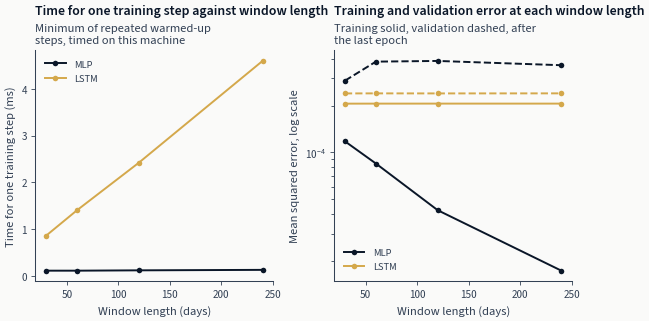

In [30]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"])

for arch, color in (("MLP", COLORS["blue"]), ("LSTM", COLORS["amber"])):
    axes[0].plot(
        LOOKBACKS,
        [scaling_results[(arch, lb)]["time"] for lb in LOOKBACKS],
        "o-",
        color=color,
        label=arch,
    )
    axes[1].plot(
        LOOKBACKS,
        [scaling_results[(arch, lb)]["train_mse"] for lb in LOOKBACKS],
        "o-",
        color=color,
        label=arch,
    )
    axes[1].plot(
        LOOKBACKS,
        [scaling_results[(arch, lb)]["val_mse"] for lb in LOOKBACKS],
        "o--",
        color=color,
    )

axes[0].set_xlabel("Window length (days)")
axes[0].set_ylabel("Time for one training step (ms)")
add_message_title(
    axes[0],
    "Time for one training step against window length",
    subtitle="Minimum of repeated warmed-up steps, timed on this machine",
)
axes[0].legend(frameon=False, fontsize="small")

axes[1].set_yscale("log")
axes[1].set_xlabel("Window length (days)")
axes[1].set_ylabel("Mean squared error, log scale")
add_message_title(
    axes[1],
    "Training and validation error at each window length",
    subtitle="Training solid, validation dashed, after the last epoch",
)
axes[1].legend(frameon=False, fontsize="small")

show_with_alt(
    fig,
    "Two panels sharing a horizontal axis of window length in days. The left panel "
    "plots the time for one training step for the fully connected network and the "
    "LSTM; the right panel plots each one's training error as a solid line and its "
    "validation error as a dashed line, on a logarithmic scale.",
)

The two panels are the notebook's argument in one figure, and they say different
things about the same lengthening.

On the left, the recurrent network is slower than the fully connected one at every
length measured, and its cost climbs with the window while the fully connected one's
stays close to flat. That is the sequential cost: a longer window is more dependent
steps for the recurrent network, where for the fully connected network it is one
larger matrix multiplication into a wider first layer.

Read the levels and the gap between the two curves rather than the exact slope of
either. A step here is a few milliseconds, and a minimum over repeated warmed-up steps
is still sensitive to what else the machine is doing - on a loaded machine the same
sweep produces a visibly noisier left panel, with the ordering intact and the
monotonicity gone.

On the right, the two curves for each architecture separate rather than descend
together. A longer window gives the fully connected network more input slots and
therefore more capacity to fit the training days exactly, and its training error
drops accordingly; the validation error it is supposed to predict does not follow.
The recurrent network keeps the same weights however long the window is, so it has no
extra capacity to spend and both of its curves stay flat. Neither architecture turns
the extra history into a better forecast. The distance between a training curve and
its validation curve is the part of the drop that was never real, and reading the
left panel without the right one would price compute against exactly that.

**What this does not establish.** One chronological cut of one eight-fund panel says
nothing durable about which architecture forecasts better on financial data. Chapter
6 sets out the walk-forward procedure needed to make a claim of that kind, and the
case-study notebooks apply it.

## Key takeaways

1. **Compare architectures on one input and one training procedure.** Everything in
   this notebook - the windows, the split, the optimiser, the number of epochs, the
   seed - is shared, so a difference between two rows of the results table is a
   difference between two architectures rather than between two experiments. Setting
   that up is most of the work, and skipping it is how architecture comparisons come
   to disagree with each other.
2. **Record a validation error beside the training error from the first run.** A
   training curve alone cannot distinguish a network that is learning from one that
   is memorising, and both look like progress. The second curve costs one forward
   pass per epoch.
3. **Place each example by the date of its target, and embargo the horizon.** The
   boundary that decides an example's partition is the one its target falls on, not
   the one its window starts on. An input window reaching back across a boundary is
   not leakage - at decision time the model has that history. What leaks is a
   training target resolved by days the model is later scored on, so training stops
   `HORIZON` days short of the first validation target. Nothing warns about either
   choice: the model trains, the score is computed, and a wrong one is quietly
   optimistic.
4. **Time one step, not the whole run.** Total training time on shared hardware
   measures the neighbours as much as the architecture. A warmed-up, repeated,
   minimum-of-many single step is comparable between architectures and stable enough
   to compare across window lengths.
5. **Sequential and parallel architectures scale differently in the window length,
   for a reason in the code.** A recurrent network applies the same step per day, so
   a longer window is more dependent steps and no more parameters. A fully connected
   network turns a longer window into a wider first layer, which is one larger matrix
   multiplication. Chapter 13's later architectures are attempts to keep a recurrent
   network's view of the sequence without paying for the walk: N-BEATS through
   decomposition (`02_nbeats_interpretable`), attention through parallel comparison
   of every pair of positions (`04_transformers`).
6. **More capacity and more input are not more information.** The same lengthening
   that gives a fully connected network more parameters gives it more room to fit the
   training days and no more signal to find, and the two error curves separate
   accordingly. On a target with as little structure as a next-day return, the
   architecture that cannot grow with the window is the one whose training error stays
   honest.

**Known limitations.** One chronological split of eight funds, one target horizon,
one seed, and no hyperparameter search: nothing here establishes which architecture
forecasts better, and the ranking correlations are far too small to try. Timing is a
property of this machine and this PyTorch build; the ordering and the scaling
survive a change of hardware, the milliseconds do not. And a rank correlation taken
over eight funds is a coarse instrument: one fund changing place moves it a long way,
so the daily figures are noisy even before the averaging.

**Next**: `02_nbeats_interpretable` builds the first architecture designed to keep
the accuracy without the walk.